# Tema 8 - Modelos de Pequeña Señal

**Fundamentos de Electrónica - 2º GIERM**

---

## Objetivos de aprendizaje

- Comprender por qué se necesitan modelos de pequeña señal y cómo se obtienen por linealización
- Dominar la notación de señales (total, DC, AC) y su convención de mayúsculas/minúsculas
- Obtener y aplicar el modelo de pequeña señal del **diodo**
- Obtener y aplicar los modelos de pequeña señal del **BJT** (parámetros H y π)
- Obtener y aplicar el modelo de pequeña señal del **MOSFET**
- Resolver circuitos mixtos DC+AC mediante superposición (separar problema DC y AC)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D
import schemdraw
import schemdraw.elements as elm

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['figure.dpi'] = 100

COLOR_PRINCIPAL = '#2171b5'   # azul - curvas principales
COLOR_RECTA = '#cb181d'       # rojo - rectas de carga, tangentes
COLOR_PUNTO = '#238b45'       # verde - puntos de operación
COLOR_AC = '#ff7f00'          # naranja - componente AC
COLOR_DC = '#6a3d9a'          # morado - componente DC

print('Configuración lista.')

Configuración lista.


---

## 1. Introducción: ¿Por qué modelos de pequeña señal?

Los modelos de **gran señal** (exponencial del diodo, cuadrática del MOSFET) describen el comportamiento completo del dispositivo, pero presentan un problema fundamental: **son ecuaciones no lineales**.

Cuando un circuito tiene simultáneamente señales **DC** (polarización) y **AC** (señal útil), resolver las ecuaciones no lineales de forma analítica es extremadamente difícil o imposible.

**La solución:** si la señal AC es **pequeña** comparada con la DC, podemos **linealizar** el modelo alrededor del punto de operación. Esto convierte el dispositivo no lineal en un circuito de **resistencias y fuentes controladas**, que se resuelve con las herramientas lineales de siempre (KVL, KCL, superposición, Thévenin...).

> **Analogía:** Es como aproximar una curva por su recta tangente. Si te mueves poco alrededor del punto de tangencia, la recta es una excelente aproximación.

---

## 2. Componentes de una señal: DC + AC

Cualquier señal en un circuito electrónico se puede descomponer en:

$$v_I(t) = V_I + v_i(t)$$

donde:
- $v_I(t)$: valor instantáneo **total** de la señal
- $V_I$: componente **DC** (punto de operación, constante)
- $v_i(t)$: componente **AC** (pequeña señal, variable en el tiempo)

### Convención de notación (MUY IMPORTANTE)

| Notación | Significado | Ejemplo |
|----------|-------------|----------|
| $v_I$, $i_I$ (variable minúscula, subíndice MAYÚSCULA) | Valor instantáneo **total** | $v_I(t) = 1 + 0.05\sin(\omega t)$ V |
| $V_I$, $I_I$ (variable MAYÚSCULA, subíndice MAYÚSCULA) | Valor **DC** (polarización) | $V_I = 1$ V |
| $v_i$, $i_i$ (variable minúscula, subíndice minúscula) | Componente **AC** (pequeña señal) | $v_i(t) = 0.05\sin(\omega t)$ V |

> **Truco para el examen:** Fíjate siempre en las mayúsculas/minúsculas. Un error de notación puede llevar a confundir la señal total con solo la componente AC.

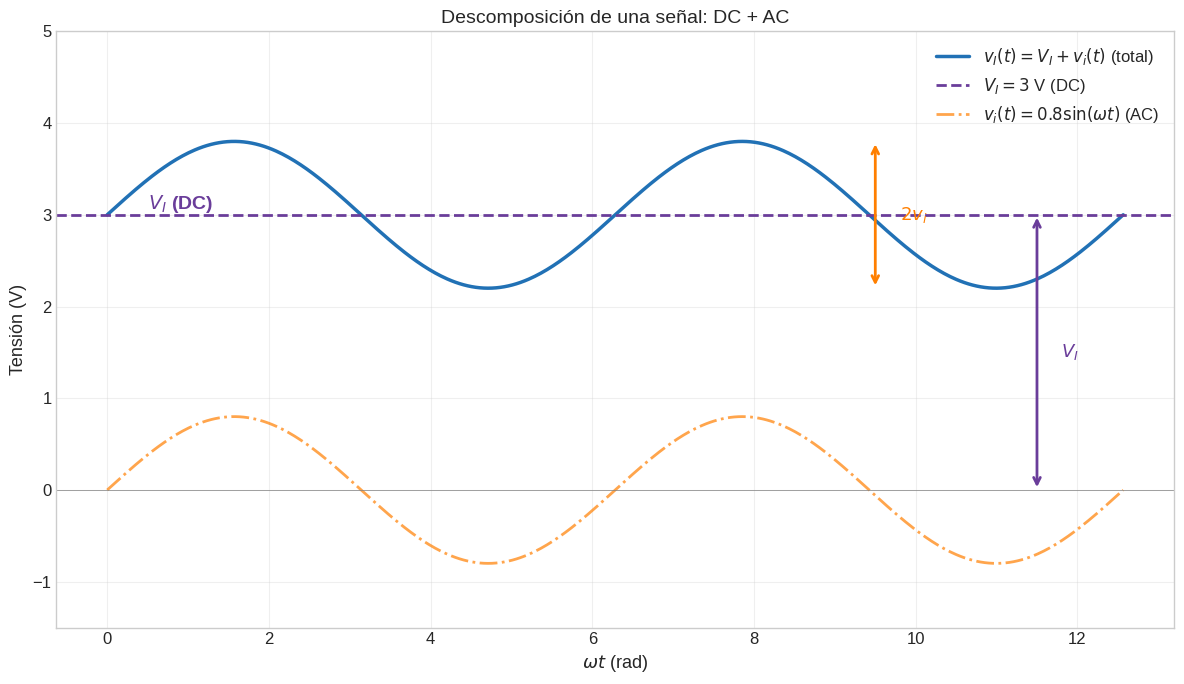

In [2]:
# Gráfica: señal con componentes DC y AC
fig, ax = plt.subplots(figsize=(12, 7))

t = np.linspace(0, 4 * np.pi, 500)
V_DC = 3.0        # componente DC
V_ac = 0.8        # amplitud AC
v_total = V_DC + V_ac * np.sin(t)
v_ac = V_ac * np.sin(t)

# Señal total
ax.plot(t, v_total, color=COLOR_PRINCIPAL, lw=2.5,
        label=r'$v_I(t) = V_I + v_i(t)$ (total)')

# Componente DC
ax.axhline(y=V_DC, color=COLOR_DC, lw=2, ls='--',
           label=r'$V_I = 3$ V (DC)')

# Componente AC (referida a cero para visualizar)
ax.plot(t, v_ac, color=COLOR_AC, lw=2, ls='-.',
        alpha=0.7, label=r'$v_i(t) = 0.8 \sin(\omega t)$ (AC)')
ax.axhline(y=0, color='gray', lw=0.5)

# Anotaciones
ax.annotate(r'$V_I$ (DC)', xy=(0.5, V_DC), fontsize=14,
            color=COLOR_DC, fontweight='bold', va='bottom')

ax.annotate('', xy=(9.5, V_DC + V_ac), xytext=(9.5, V_DC - V_ac),
            arrowprops=dict(arrowstyle='<->', color=COLOR_AC, lw=2))
ax.text(9.8, V_DC, r'$2 v_i$', fontsize=13, color=COLOR_AC,
        fontweight='bold', va='center')

ax.annotate('', xy=(11.5, 0), xytext=(11.5, V_DC),
            arrowprops=dict(arrowstyle='<->', color=COLOR_DC, lw=2))
ax.text(11.8, V_DC / 2, r'$V_I$', fontsize=13, color=COLOR_DC,
        fontweight='bold', va='center')

ax.set_xlabel(r'$\omega t$ (rad)')
ax.set_ylabel(r'Tensión (V)')
ax.set_title('Descomposición de una señal: DC + AC')
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_ylim(-1.5, 5)
plt.tight_layout()
plt.show()

---

## 3. Modelos incrementales

### Del modelo de gran señal al modelo incremental

- **Modelo de gran señal:** da la relación $i = f(v)$ para **cualquier** punto de la curva característica.
- **Modelo incremental:** da la relación entre **cambios** $\Delta i = f(\Delta v)$ alrededor de un punto de operación $Q$.

La idea clave es que el modelo incremental **depende del punto de operación** $Q$. Un mismo dispositivo tiene distintos modelos incrementales según dónde esté polarizado.

**Gráficamente:** el modelo incremental es la **recta tangente** a la curva característica en el punto $Q$.

$$\boxed{\Delta i \approx \left.\frac{di}{dv}\right|_Q \cdot \Delta v = g_Q \cdot \Delta v}$$

donde $g_Q$ es la **conductancia incremental** (pendiente de la tangente en $Q$).

---

## 4. Del modelo incremental al modelo de pequeña señal

El modelo de **pequeña señal** es el modelo incremental cuando la amplitud de la señal AC es **suficientemente pequeña** para que la curva se aproxime bien por su tangente.

¿Cuándo es "suficientemente pequeña"? Cuando:
- La señal AC es mucho menor que los valores DC: $v_i \ll V_I$
- En la práctica: $v_i < \phi_T \approx 26$ mV para el diodo/BJT

**Consecuencia fundamental:** el modelo de pequeña señal es **LINEAL**. Esto permite usar:
- **Superposición** (separar DC y AC)
- **KVL y KCL** directamente
- **Thévenin y Norton**
- **Análisis de mallas y nodos**

> **Resumen:** Gran señal (no lineal) $\to$ Incremental (tangente en Q) $\to$ Pequeña señal (lineal si la AC es pequeña)

---

## 5. Modelo de pequeña señal del DIODO

### Modelo de gran señal

$$i_D = I_0 \left(e^{v_D / \phi_T} - 1\right)$$

### Derivación del modelo de pequeña señal

La conductancia incremental se obtiene derivando:

$$g_d = \left.\frac{dI_D}{dv_D}\right|_Q = \frac{I_0}{\phi_T} \cdot e^{V_D / \phi_T} \approx \frac{I_D}{\phi_T}$$

La **resistencia de pequeña señal** del diodo es:

$$\boxed{r_d = \frac{1}{g_d} = \frac{\phi_T}{I_D}}$$

donde $\phi_T \approx 26$ mV a temperatura ambiente.

### Modelo equivalente

El diodo en pequeña señal se comporta como una **simple resistencia** $r_d$:

$$i_d = g_d \cdot v_d = \frac{v_d}{r_d}$$

### Modelo completo con capacitancias

Para altas frecuencias, se añaden dos capacitancias en paralelo con $r_d$:
- $C_{dif}$: capacitancia de **difusión** (proporcional a $I_D$, dominante en directa)
- $C_{tran}$: capacitancia de **transición** (depende de $V_D$, dominante en inversa)

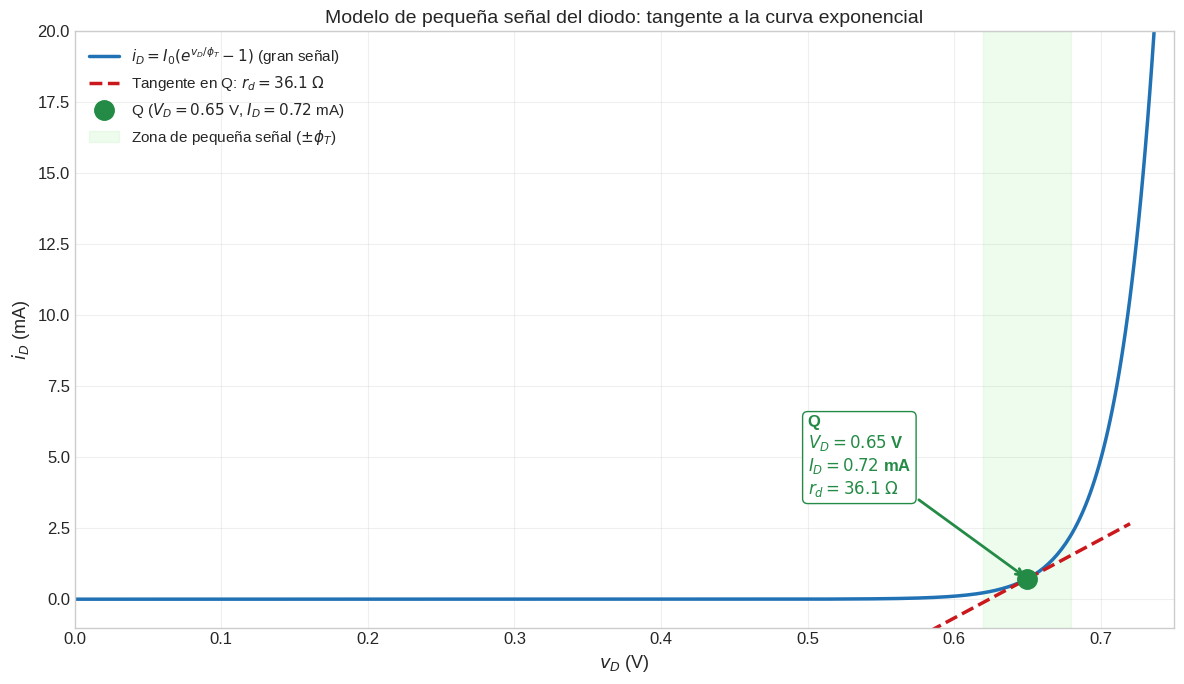

In [3]:
# Curva exponencial del diodo con tangente en el punto Q
fig, ax = plt.subplots(figsize=(12, 7))

phi_T = 26e-3  # 26 mV
I0 = 1e-14     # corriente de saturación

# Curva del diodo
v_D = np.linspace(0, 0.75, 500)
i_D = I0 * (np.exp(v_D / phi_T) - 1)

# Punto de operación Q
V_Q = 0.65
I_Q = I0 * (np.exp(V_Q / phi_T) - 1)

# Pendiente (conductancia) en Q
g_d = I_Q / phi_T
r_d = 1 / g_d

# Recta tangente
v_tang = np.linspace(0.55, 0.72, 100)
i_tang = I_Q + g_d * (v_tang - V_Q)

# Curva principal
ax.plot(v_D, i_D * 1e3, color=COLOR_PRINCIPAL, lw=2.5,
        label=r'$i_D = I_0(e^{v_D/\phi_T} - 1)$ (gran señal)')

# Tangente
ax.plot(v_tang, i_tang * 1e3, color=COLOR_RECTA, lw=2.5, ls='--',
        label=r'Tangente en Q: $r_d = %.1f$ $\Omega$' % r_d)

# Punto Q
ax.plot(V_Q, I_Q * 1e3, 'o', color=COLOR_PUNTO, ms=14, zorder=5,
        label=r'Q ($V_D=%.2f$ V, $I_D=%.2f$ mA)' % (V_Q, I_Q * 1e3))

# Anotación
ax.annotate(r'Q' + '\n' + r'$V_D = %.2f$ V' % V_Q + '\n' +
            r'$I_D = %.2f$ mA' % (I_Q * 1e3) + '\n' +
            r'$r_d = %.1f$ $\Omega$' % r_d,
            xy=(V_Q, I_Q * 1e3), xytext=(V_Q - 0.15, I_Q * 1e3 + 3),
            fontsize=12, color=COLOR_PUNTO, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=2),
            bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_PUNTO))

# Zona de pequeña señal
ax.axvspan(V_Q - 0.03, V_Q + 0.03, alpha=0.15, color='lightgreen',
           label=r'Zona de pequeña señal ($\pm \phi_T$)')

ax.set_xlabel(r'$v_D$ (V)')
ax.set_ylabel(r'$i_D$ (mA)')
ax.set_title('Modelo de pequeña señal del diodo: tangente a la curva exponencial')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_ylim(-1, 20)
ax.set_xlim(0, 0.75)
plt.tight_layout()
plt.show()

#### Ejercicio resuelto: Resistencia de pequeña señal del diodo

**Datos:** $I_D = 1$ mA, $\phi_T = 26$ mV

**Paso 1:** Aplicar la fórmula de $r_d$:

$$r_d = \frac{\phi_T}{I_D} = \frac{26\;\text{mV}}{1\;\text{mA}} = 26\;\Omega$$

**Resultado:** $\boxed{r_d = 26\;\Omega}$

> **Regla rápida:** A $I_D = 1$ mA, $r_d = 26\;\Omega$. Si $I_D$ se duplica, $r_d$ se reduce a la mitad. Si $I_D = 0.1$ mA, $r_d = 260\;\Omega$.

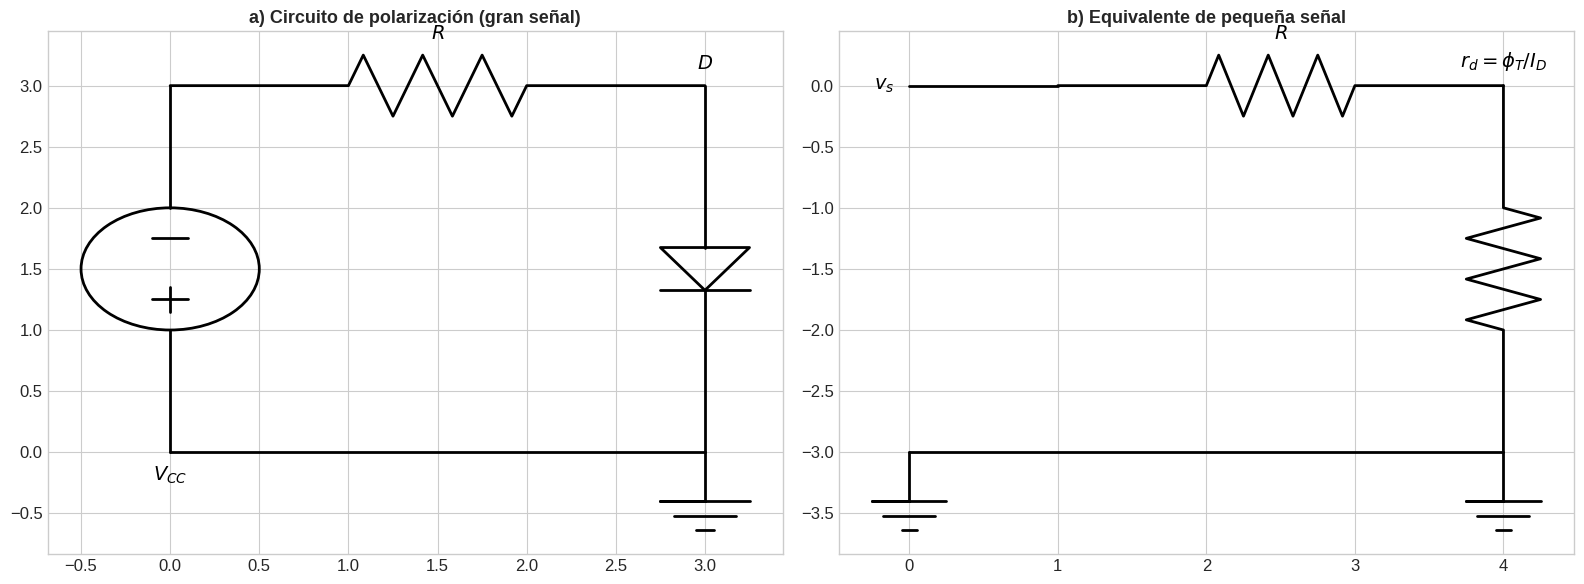

In [4]:
# Diodo: circuito de gran señal vs equivalente de pequeña señal
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# a) Gran señal (DC)
ax = axes[0]
ax.set_title(r'a) Circuito de polarización (gran señal)', fontsize=13, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.SourceV().up().label(r'$V_{CC}$', loc='left').reverse()
d += elm.Resistor().right().label(r'$R$', loc='top')
d += elm.Diode().down().label(r'$D$', loc='right')
d += elm.Ground()
d += elm.Line().left().tox(d.elements[0].start)
d.draw()

# b) Pequeña señal (AC)
ax = axes[1]
ax.set_title(r'b) Equivalente de pequeña señal', fontsize=13, fontweight='bold')
d2 = schemdraw.Drawing(canvas=ax)
d2 += elm.Line().right().length(1).label(r'$v_s$', loc='left')
d2 += elm.Resistor().right().label(r'$R$', loc='top')
d2 += elm.Resistor().down().label(r'$r_d = \phi_T / I_D$', loc='right')
d2 += elm.Ground()
d2 += elm.Line().left().length(4)
d2 += elm.Ground()
d2.draw()

plt.tight_layout(); plt.show()

---

## 6. Modelo de pequeña señal del BJT

El BJT es un dispositivo con **dos puertos** (entrada: base-emisor, salida: colector-emisor) y **dos variables independientes** ($i_B$ y $v_{CE}$). Por tanto, necesitamos **dos ecuaciones** para describirlo.

### Gran señal

$$v_{BE} = v_{BE}(v_{CE}, i_B) \qquad i_C = i_C(v_{CE}, i_B)$$

### Pequeña señal (linealización)

Al linealizar funciones de dos variables, obtenemos un **plano tangente** (no una recta):

$$v_{be} = \frac{\partial v_{BE}}{\partial i_B}\bigg|_Q \cdot i_b + \frac{\partial v_{BE}}{\partial v_{CE}}\bigg|_Q \cdot v_{ce}$$

$$i_c = \frac{\partial i_C}{\partial i_B}\bigg|_Q \cdot i_b + \frac{\partial i_C}{\partial v_{CE}}\bigg|_Q \cdot v_{ce}$$

### 6.1 Modelo de parámetros H (*Hybrid*)

Definiendo los **parámetros híbridos**:

$$\boxed{v_{be} = h_{ie} \cdot i_b + h_{re} \cdot v_{ce}}$$

$$\boxed{i_c = h_{fe} \cdot i_b + h_{oe} \cdot v_{ce}}$$

| Parámetro | Definición | Expresión | Valor típico |
|-----------|-----------|-----------|-------------|
| $h_{ie}$ | $\dfrac{\partial v_{BE}}{\partial i_B}\bigg\|_Q$ | $\beta \cdot \dfrac{\phi_T}{I_C}$ | 1 - 3 k$\Omega$ |
| $h_{re}$ | $\dfrac{\partial v_{BE}}{\partial v_{CE}}\bigg\|_Q$ | $\dfrac{\phi_T}{V_A}$ | $\sim 10^{-4}$ (se desprecia) |
| $h_{fe}$ | $\dfrac{\partial i_C}{\partial i_B}\bigg\|_Q$ | $\beta$ | 100 - 300 |
| $h_{oe}$ | $\dfrac{\partial i_C}{\partial v_{CE}}\bigg\|_Q$ | $\dfrac{I_C}{V_A}$ | $\sim (80\;\text{k}\Omega)^{-1}$ (se desprecia) |

> **Nota:** $V_A$ es la tensión de *Early*. Cuanto mayor es $V_A$, más ideal es el transistor ($h_{re} \to 0$, $h_{oe} \to 0$).

### 6.2 Modelo de parámetros π

El modelo π describe el BJT como un circuito con resistencias y una fuente de corriente controlada:

| Elemento | Símbolo | Relación con H |
|----------|---------|----------------|
| Resistencia base-emisor | $r_{be}$ | $r_{be} = h_{ie}$ |
| Transconductancia | $g_m$ | $g_m = \dfrac{h_{fe}}{h_{ie}} = \dfrac{I_C}{\phi_T}$ |
| Resistencia colector-emisor | $r_{ce}$ | $r_{ce} = \dfrac{1}{h_{oe}} = \dfrac{V_A}{I_C}$ |
| Resistencia base-colector | $r_{bc}$ | Se desprecia habitualmente |

**Ecuaciones del modelo π:**

$$\boxed{g_m = \frac{I_C}{\phi_T}} \qquad \boxed{r_{be} = \frac{\beta}{g_m} = \frac{\beta \cdot \phi_T}{I_C}}$$

**Relaciones entre modelos:**

$$h_{ie} = r_{be} \qquad h_{fe} = g_m \cdot r_{be} \qquad h_{oe}^{-1} = r_{ce}$$

### 6.3 Modelos simplificados (despreciando $h_{re}$ y $h_{oe}$)

En la mayoría de ejercicios se desprecian $h_{re}$ y $h_{oe}$ porque son muy pequeños:

**Modelo H simplificado:**

$$v_{be} = h_{ie} \cdot i_b \qquad i_c = h_{fe} \cdot i_b = \beta \cdot i_b$$

**Modelo π simplificado:**

$$i_c = g_m \cdot v_{be} \qquad \text{con } r_{be} \text{ en la entrada}$$

> **¿Cuándo usar el modelo completo?** Solo cuando el enunciado lo pida explícitamente o cuando se necesite calcular la resistencia de salida del circuito (donde $r_{ce}$ importa).

#### Ejercicio resuelto: Parámetros de pequeña señal del BJT

**Datos:** $\beta = 100$, $I_C = 2$ mA, $V_A = 100$ V, $\phi_T = 26$ mV

**Paso 1:** Calcular la transconductancia $g_m$:

$$g_m = \frac{I_C}{\phi_T} = \frac{2\;\text{mA}}{26\;\text{mV}} = 76.92\;\text{mA/V}$$

**Paso 2:** Calcular los parámetros H:

$$h_{ie} = \frac{\beta \cdot \phi_T}{I_C} = \frac{100 \times 26\;\text{mV}}{2\;\text{mA}} = 1300\;\Omega = 1.3\;\text{k}\Omega$$

$$h_{fe} = \beta = 100$$

$$h_{re} = \frac{\phi_T}{V_A} = \frac{26\;\text{mV}}{100\;\text{V}} = 2.6 \times 10^{-4} \approx 0$$

$$h_{oe} = \frac{I_C}{V_A} = \frac{2\;\text{mA}}{100\;\text{V}} = 20\;\mu\text{S} \;\;\left(\frac{1}{h_{oe}} = 50\;\text{k}\Omega\right)$$

**Paso 3:** Calcular los parámetros π:

$$r_{be} = h_{ie} = 1.3\;\text{k}\Omega$$

$$g_m = 76.92\;\text{mA/V}$$

$$r_{ce} = \frac{1}{h_{oe}} = \frac{V_A}{I_C} = \frac{100}{2 \times 10^{-3}} = 50\;\text{k}\Omega$$

**Verificación:** $h_{fe} = g_m \cdot r_{be} = 76.92 \times 10^{-3} \times 1300 = 100 = \beta$ $\checkmark$

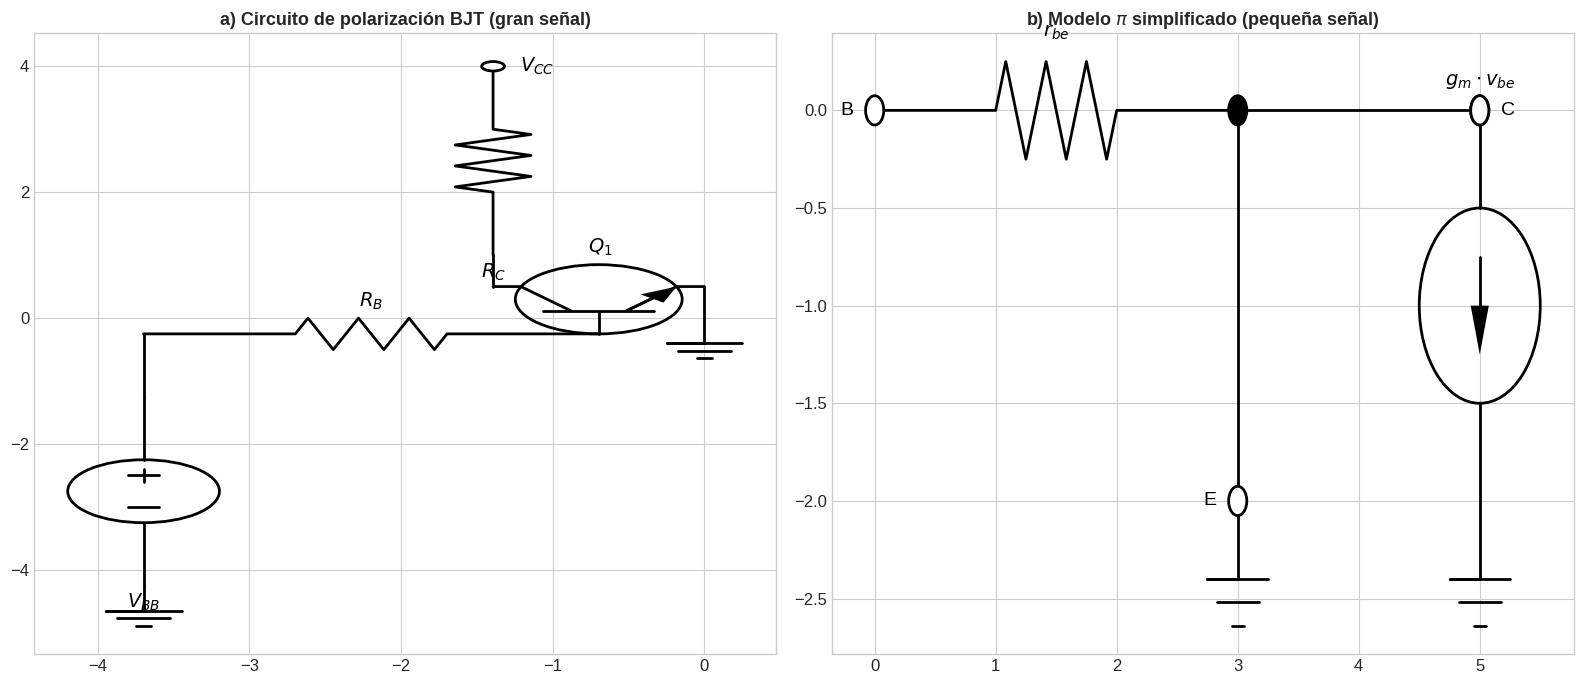

In [5]:
# BJT: circuito de polarización vs equivalente de pequeña señal (modelo π)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# a) Gran señal
ax = axes[0]
ax.set_title(r'a) Circuito de polarización BJT (gran señal)', fontsize=13, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.Ground()
d += elm.Line().up().length(0.5)
d += elm.BjtNpn(circle=True).anchor('emitter').label(r'$Q_1$', loc='right')
bjt = d.elements[-1]
d += elm.Line().at(bjt.collector).up().length(0.5)
d += elm.Resistor().up().label(r'$R_C$', loc='left')
d += elm.Dot(open=True).label(r'$V_{CC}$', loc='right')
top = d.here
d += elm.Resistor().at(bjt.base).left().length(3).label(r'$R_B$', loc='top')
d += elm.Line().down().length(1)
d += elm.SourceV().down().label(r'$V_{BB}$', loc='left').reverse()
d += elm.Ground()
d.draw()

# b) Pequeña señal (modelo π simplificado)
ax = axes[1]
ax.set_title(r'b) Modelo $\pi$ simplificado (pequeña señal)', fontsize=13, fontweight='bold')
d2 = schemdraw.Drawing(canvas=ax)
# Base
d2 += elm.Dot(open=True).label('B', loc='left')
d2 += elm.Resistor().right().label(r'$r_{be}$', loc='top')
d2 += elm.Dot()
mid = d2.here
# rbe to ground (emitter)
d2 += elm.Line().down().length(2)
d2 += elm.Ground()
d2 += elm.Dot(open=True).label('E', loc='left')
# Collector side
d2 += elm.Line().at(mid).right().length(2)
d2 += elm.Dot()
col = d2.here
d2 += elm.SourceI().down().length(2).label(r'$g_m \cdot v_{be}$', loc='right')
d2 += elm.Ground()
# Collector terminal
d2 += elm.Dot(open=True).at(col).label('C', loc='right')
d2.draw()

plt.tight_layout(); plt.show()

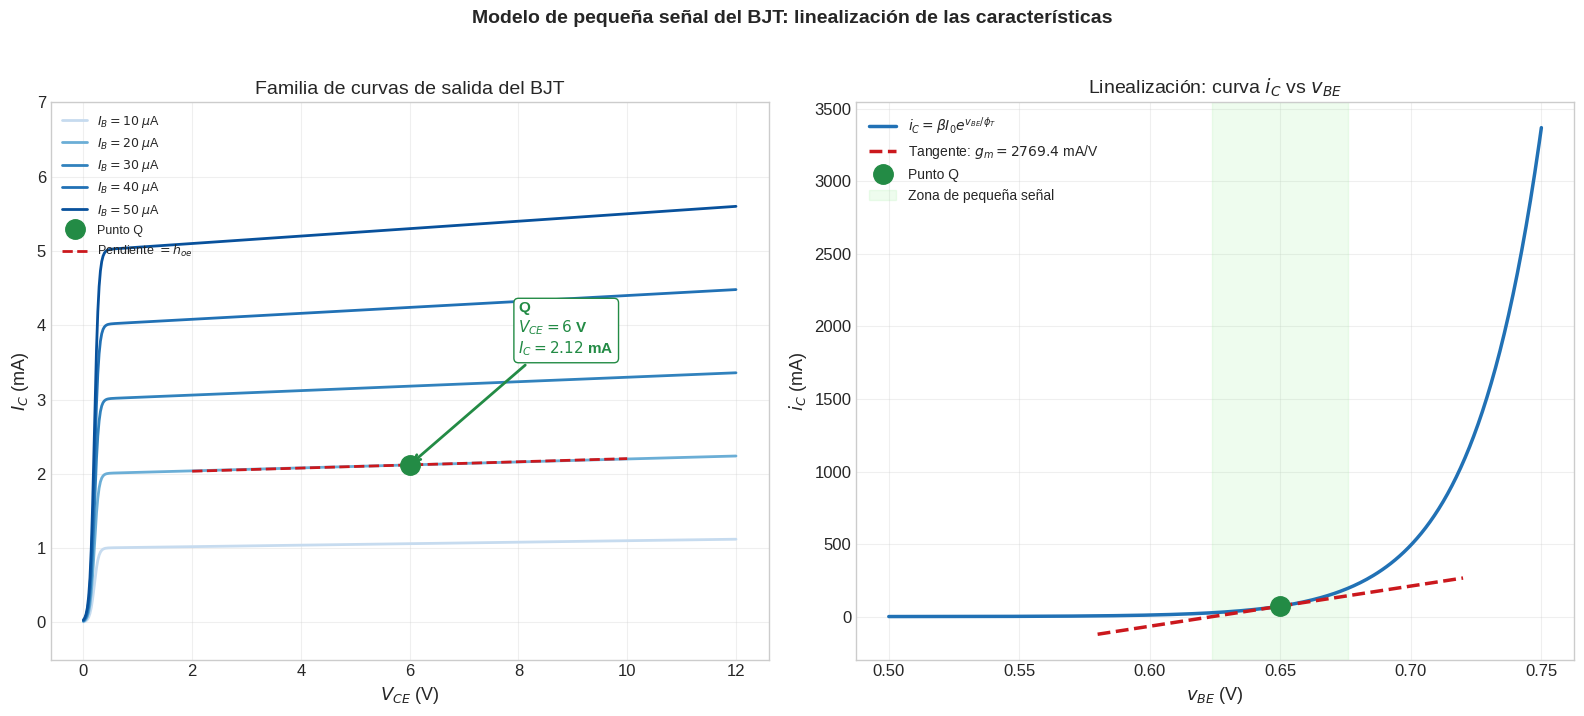

In [6]:
# Familia de curvas de salida del BJT con concepto de tangente
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

beta = 100
V_A = 100
V_CE = np.linspace(0, 12, 500)

# Panel izquierdo: familia de curvas
ax = axes[0]
ib_values = [10e-6, 20e-6, 30e-6, 40e-6, 50e-6]
colors_ib = ['#c6dbef', '#6baed6', '#3182bd', '#2171b5', '#08519c']

for ib, color in zip(ib_values, colors_ib):
    ic = beta * ib * (1 + V_CE / V_A) * np.clip(
        (np.tanh((V_CE - 0.2) / 0.08) + 1) / 2, 0, 1)
    ax.plot(V_CE, ic * 1e3, color=color, lw=2,
            label=r'$I_B = %.0f$ $\mu$A' % (ib * 1e6))

# Punto Q en la curva de I_B = 20 uA
ib_q = 20e-6
V_CE_Q = 6.0
I_C_Q = beta * ib_q * (1 + V_CE_Q / V_A)

ax.plot(V_CE_Q, I_C_Q * 1e3, 'o', color=COLOR_PUNTO, ms=14, zorder=5,
        label='Punto Q')
ax.annotate('Q\n' + r'$V_{CE}=%.0f$ V' % V_CE_Q + '\n' +
            r'$I_C=%.2f$ mA' % (I_C_Q * 1e3),
            xy=(V_CE_Q, I_C_Q * 1e3),
            xytext=(V_CE_Q + 2, I_C_Q * 1e3 + 1.5),
            fontsize=11, color=COLOR_PUNTO, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=2),
            bbox=dict(boxstyle='round', facecolor='white',
                      edgecolor=COLOR_PUNTO))

# Tangente (pendiente = h_oe)
h_oe = I_C_Q / V_A
v_tang = np.linspace(2, 10, 100)
i_tang = I_C_Q + h_oe * (v_tang - V_CE_Q)
ax.plot(v_tang, i_tang * 1e3, color=COLOR_RECTA, lw=2, ls='--',
        label=r'Pendiente $= h_{oe}$')

ax.set_xlabel(r'$V_{CE}$ (V)')
ax.set_ylabel(r'$I_C$ (mA)')
ax.set_title('Familia de curvas de salida del BJT')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.5, 7)

# Panel derecho: linealización i_C vs v_BE
ax2 = axes[1]

phi_T = 26e-3
v_BE = np.linspace(0.5, 0.75, 300)
I0_be = 1e-14
i_C_be = beta * I0_be * np.exp(v_BE / phi_T)

V_BE_Q = 0.65
I_C_Q2 = beta * I0_be * np.exp(V_BE_Q / phi_T)
gm = I_C_Q2 / phi_T

v_tang2 = np.linspace(0.58, 0.72, 100)
i_tang2 = I_C_Q2 + gm * (v_tang2 - V_BE_Q)

ax2.plot(v_BE, i_C_be * 1e3, color=COLOR_PRINCIPAL, lw=2.5,
         label=r'$i_C = \beta I_0 e^{v_{BE}/\phi_T}$')
ax2.plot(v_tang2, i_tang2 * 1e3, color=COLOR_RECTA, lw=2.5, ls='--',
         label=r'Tangente: $g_m = %.1f$ mA/V' % (gm * 1e3))
ax2.plot(V_BE_Q, I_C_Q2 * 1e3, 'o', color=COLOR_PUNTO, ms=14, zorder=5,
         label='Punto Q')

ax2.axvspan(V_BE_Q - phi_T, V_BE_Q + phi_T, alpha=0.15,
            color='lightgreen', label=r'Zona de pequeña señal')

ax2.set_xlabel(r'$v_{BE}$ (V)')
ax2.set_ylabel(r'$i_C$ (mA)')
ax2.set_title(r'Linealización: curva $i_C$ vs $v_{BE}$')
ax2.legend(fontsize=10, loc='upper left')
ax2.grid(True, alpha=0.3)

plt.suptitle(
    'Modelo de pequeña señal del BJT: linealización de las características',
    fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 7. Modelo de pequeña señal del MOSFET

### Modelo de gran señal (saturación)

$$i_D = \frac{K_n}{2}(v_{GS} - V_T)^2(1 + \lambda \cdot v_{DS})$$

donde $V_T$ puede depender de $V_{SB}$ (efecto *body*).

### Pequeña señal: TRES variables independientes

A diferencia del BJT, el MOSFET tiene **tres** variables independientes ($v_{GS}$, $v_{DS}$, $v_{BS}$), lo que da lugar a **tres términos** en la ecuación de pequeña señal:

$$\boxed{i_d = g_m \cdot v_{gs} + g_{mb} \cdot v_{bs} + g_o \cdot v_{ds}}$$

### Parámetros de pequeña señal

| Parámetro | Definición | Expresión | Significado |
|-----------|-----------|-----------|-------------|
| $g_m$ | $\dfrac{\partial i_D}{\partial v_{GS}}\bigg\|_M$ | $\sqrt{2 K_n I_D} = \dfrac{2 I_D}{V_{GS} - V_T}$ | **Transconductancia** |
| $g_o$ | $\dfrac{\partial i_D}{\partial v_{DS}}\bigg\|_M$ | $\lambda \cdot I_D$ | **Conductancia de salida** |
| $g_{mb}$ | $\dfrac{\partial i_D}{\partial v_{BS}}\bigg\|_M$ | $\dfrac{\gamma \cdot g_m}{2\sqrt{\phi_{H0} + V_{SB}}}$ | **Transconductancia del *body*** |
| $r_o$ | $1 / g_o$ | $\dfrac{1}{\lambda \cdot I_D}$ | **Resistencia de salida** |

### Diferencias clave con el BJT

- **No hay corriente de puerta:** $i_g = 0$ (impedancia de entrada infinita)
- **No hay corriente de *body*:** $i_b = 0$
- La transconductancia $g_m$ del MOSFET es generalmente **menor** que la del BJT para la misma corriente

### Modelo simplificado ($V_{BS} = 0$)

Cuando el sustrato está conectado al surtidor ($V_{BS} = 0$):

$$i_d = g_m \cdot v_{gs} + g_o \cdot v_{ds}$$

Solo quedan la fuente controlada $g_m \cdot v_{gs}$ y la resistencia $r_o$ en paralelo.

### Modelo con capacitancias (altas frecuencias)

El modelo completo incluye: $C_{gs}$, $C_{gd}$, $C_{gb}$, $C_{bs}$, $C_{bd}$.

#### Ejercicio resuelto: Parámetros de pequeña señal del MOSFET

**Datos:** $K_n = 4$ mA/V$^2$, $I_D = 2$ mA, $V_{GS} = 3$ V, $V_T = 1$ V, $\lambda = 0.02$ V$^{-1}$

**Paso 1:** Verificar saturación:

$$V_{GS} - V_T = 3 - 1 = 2\;\text{V}$$

Necesitamos $V_{DS} > V_{GS} - V_T = 2$ V para saturación (se asume que sí).

**Paso 2:** Calcular $g_m$ (dos formas equivalentes):

$$g_m = \sqrt{2 K_n I_D} = \sqrt{2 \times 4 \times 10^{-3} \times 2 \times 10^{-3}} = \sqrt{16 \times 10^{-6}} = 4\;\text{mA/V}$$

$$g_m = \frac{2 I_D}{V_{GS} - V_T} = \frac{2 \times 2\;\text{mA}}{2\;\text{V}} = 2\;\text{mA/V}$$

> **Nota:** Ambas fórmulas dan el mismo resultado **solo** cuando $I_D = (K_n/2)(V_{GS}-V_T)^2$ se cumple exactamente. Aquí: $(K_n/2)(V_{GS}-V_T)^2 = (4/2)(2)^2 = 8$ mA $\neq 2$ mA, lo que indica que $I_D$ está fijado por el circuito. En ese caso, usamos $g_m = \sqrt{2 K_n I_D} = 4$ mA/V.

**Paso 3:** Calcular $g_o$ y $r_o$:

$$g_o = \lambda \cdot I_D = 0.02 \times 2\;\text{mA} = 40\;\mu\text{S}$$

$$\boxed{r_o = \frac{1}{g_o} = \frac{1}{0.02 \times 2 \times 10^{-3}} = 25\;\text{k}\Omega}$$

**Resumen:** $g_m = 4$ mA/V, $g_o = 40\;\mu$S, $r_o = 25$ k$\Omega$

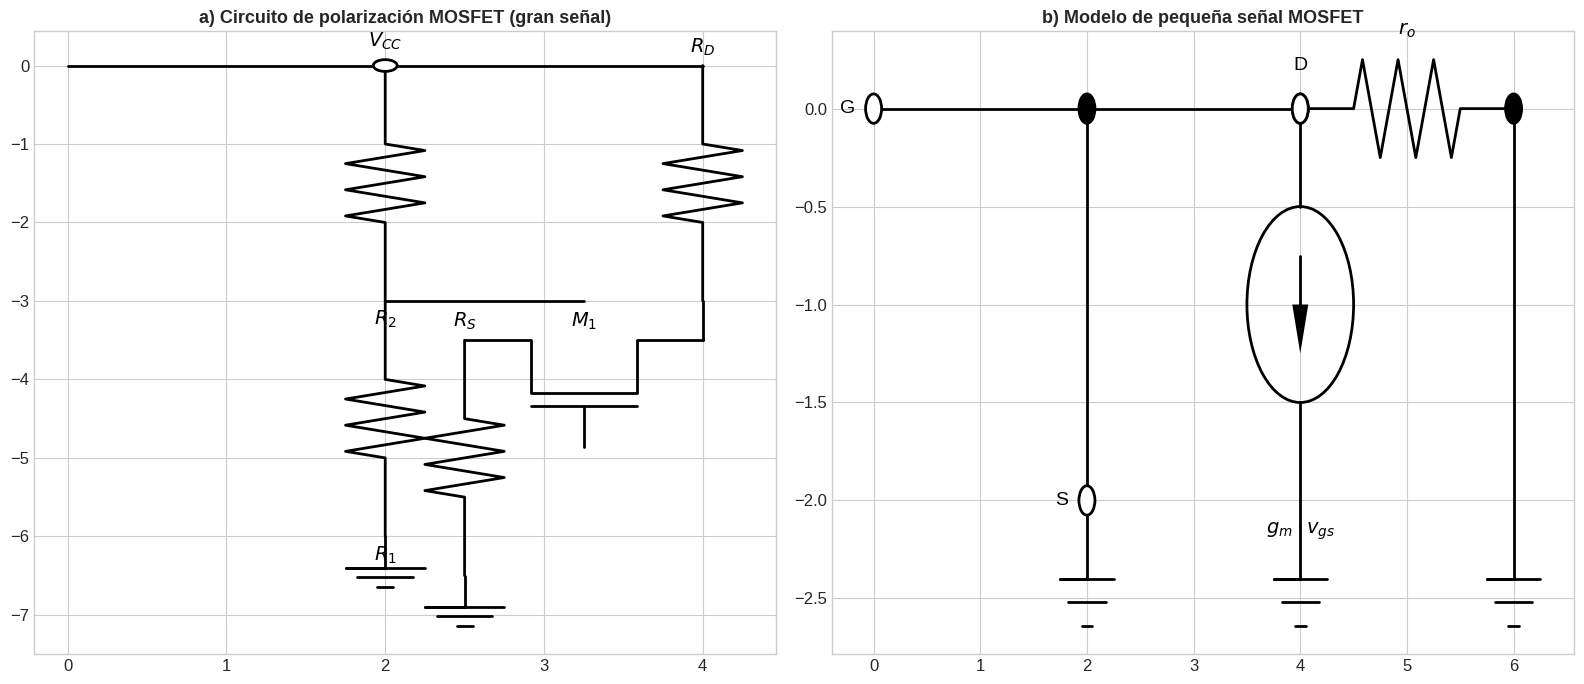

In [7]:
# MOSFET: circuito de polarización vs equivalente de pequeña señal
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# a) Gran señal
ax = axes[0]
ax.set_title(r'a) Circuito de polarización MOSFET (gran señal)', fontsize=13, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.Line().right().length(2)
d += elm.Dot(open=True).label(r'$V_{CC}$', loc='top')
top = d.here
d += elm.Line().right().length(2)
d += elm.Resistor().down().label(r'$R_D$', loc='right')
d += elm.Line().down().length(0.5)
d += elm.NFet(circle=True).anchor('drain').label(r'$M_1$', loc='right')
m = d.elements[-1]
d += elm.Resistor().at(m.source).down().label(r'$R_S$', loc='right')
d += elm.Ground()
d += elm.Resistor().at(top).down().length(3).label(r'$R_2$', loc='left')
mid = d.here
d += elm.Line().right().tox(m.gate)
d += elm.Resistor().at(mid).down().length(3).label(r'$R_1$', loc='left')
d += elm.Ground()
d.draw()

# b) Pequeña señal
ax = axes[1]
ax.set_title(r'b) Modelo de pequeña señal MOSFET', fontsize=13, fontweight='bold')
d2 = schemdraw.Drawing(canvas=ax)
d2 += elm.Dot(open=True).label('G', loc='left')
d2 += elm.Line().right().length(2)
d2 += elm.Dot()
gate = d2.here
d2 += elm.Line().down().length(2)
d2 += elm.Ground()
d2 += elm.Dot(open=True).label('S', loc='left')
# Drain side
d2 += elm.Line().at(gate).right().length(2)
d2 += elm.Dot()
drain = d2.here
d2 += elm.SourceI().down().length(2).label(r'$g_m \cdot v_{gs}$', loc='left')
d2 += elm.Ground()
# ro in parallel
d2 += elm.Resistor().at(drain).right().length(2).label(r'$r_o$', loc='top')
d2 += elm.Dot()
d2 += elm.Line().down().length(2)
d2 += elm.Ground()
d2 += elm.Dot(open=True).at(drain).label('D', loc='top')
d2.draw()

plt.tight_layout(); plt.show()

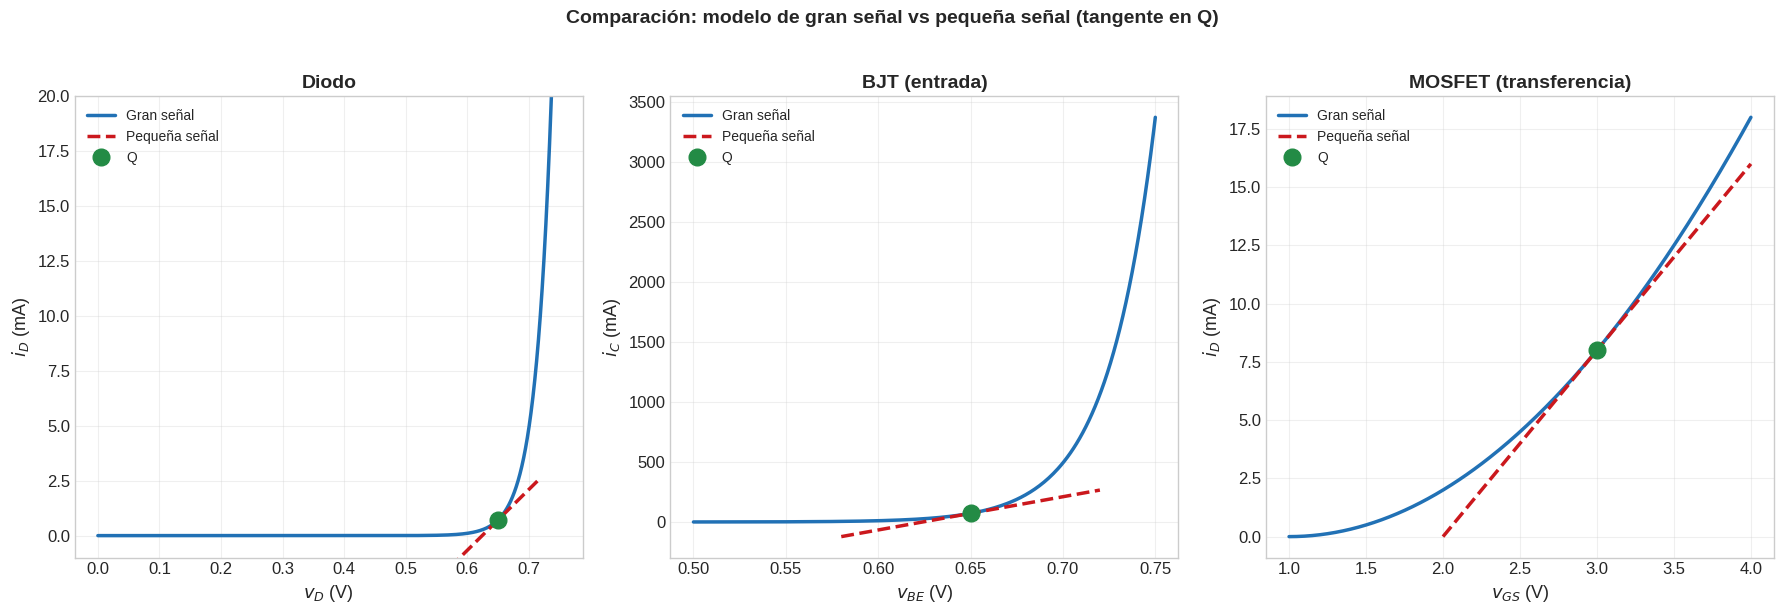

In [8]:
# Comparativa: gran señal vs pequeña señal para los tres dispositivos
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Diodo ---
ax = axes[0]
phi_T = 26e-3
I0 = 1e-14
v = np.linspace(0, 0.75, 500)
i_diode = I0 * (np.exp(v / phi_T) - 1)

V_Q = 0.65
I_Q = I0 * (np.exp(V_Q / phi_T) - 1)
g_d = I_Q / phi_T

v_lin = np.linspace(0.55, 0.72, 100)
i_lin = I_Q + g_d * (v_lin - V_Q)

ax.plot(v, i_diode * 1e3, color=COLOR_PRINCIPAL, lw=2.5,
        label='Gran señal')
ax.plot(v_lin, i_lin * 1e3, color=COLOR_RECTA, lw=2.5, ls='--',
        label='Pequeña señal')
ax.plot(V_Q, I_Q * 1e3, 'o', color=COLOR_PUNTO, ms=12, zorder=5,
        label='Q')
ax.set_xlabel(r'$v_D$ (V)')
ax.set_ylabel(r'$i_D$ (mA)')
ax.set_title('Diodo', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(-1, 20)

# --- BJT (i_C vs v_BE) ---
ax = axes[1]
beta = 100
v_BE = np.linspace(0.5, 0.75, 300)
i_C = beta * I0 * np.exp(v_BE / phi_T)

V_BE_Q = 0.65
I_C_Q = beta * I0 * np.exp(V_BE_Q / phi_T)
gm = I_C_Q / phi_T

v_lin2 = np.linspace(0.58, 0.72, 100)
i_lin2 = I_C_Q + gm * (v_lin2 - V_BE_Q)

ax.plot(v_BE, i_C * 1e3, color=COLOR_PRINCIPAL, lw=2.5,
        label='Gran señal')
ax.plot(v_lin2, i_lin2 * 1e3, color=COLOR_RECTA, lw=2.5, ls='--',
        label='Pequeña señal')
ax.plot(V_BE_Q, I_C_Q * 1e3, 'o', color=COLOR_PUNTO, ms=12, zorder=5,
        label='Q')
ax.set_xlabel(r'$v_{BE}$ (V)')
ax.set_ylabel(r'$i_C$ (mA)')
ax.set_title('BJT (entrada)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# --- MOSFET ---
ax = axes[2]
Kn = 4e-3
VT = 1.0

v_GS = np.linspace(1.0, 4.0, 300)
i_D_mos = (Kn / 2) * (v_GS - VT)**2

V_GS_Q = 3.0
I_D_Q = (Kn / 2) * (V_GS_Q - VT)**2
gm_mos = Kn * (V_GS_Q - VT)

v_lin3 = np.linspace(2.0, 4.0, 100)
i_lin3 = I_D_Q + gm_mos * (v_lin3 - V_GS_Q)

ax.plot(v_GS, i_D_mos * 1e3, color=COLOR_PRINCIPAL, lw=2.5,
        label='Gran señal')
ax.plot(v_lin3, i_lin3 * 1e3, color=COLOR_RECTA, lw=2.5, ls='--',
        label='Pequeña señal')
ax.plot(V_GS_Q, I_D_Q * 1e3, 'o', color=COLOR_PUNTO, ms=12, zorder=5,
        label='Q')
ax.set_xlabel(r'$v_{GS}$ (V)')
ax.set_ylabel(r'$i_D$ (mA)')
ax.set_title('MOSFET (transferencia)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle(
    'Comparación: modelo de gran señal vs pequeña señal (tangente en Q)',
    fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 8. Metodología general: superposición DC + AC

### El problema completo

Un circuito real tiene fuentes DC (alimentación) y fuentes AC (señal). Resolver todo junto es difícil porque los dispositivos son no lineales.

**Solución: descomponer en DOS problemas independientes:**

| Paso | Problema | Fuentes | Modelo | Incógnitas |
|------|----------|---------|--------|------------|
| 1 | **DC** | AC $= 0$ | Gran señal | $V_D$, $I_D$ (punto Q) |
| 2 | **AC** | DC $= 0$ | Pequeña señal | $v_d$, $i_d$ |
| 3 | **Combinar** | — | — | $v_{INST} = V_{DC} + v_{ac}$ |

### Reglas para el circuito AC (pequeña señal)

Al "apagar" las fuentes DC para el análisis AC:

| Elemento | En el circuito AC se convierte en... | Justificación |
|----------|---------------------------------------|---------------|
| Fuente de tensión DC | **Cortocircuito** (0 V) | No varía $\to$ $v_{ac} = 0$ |
| Fuente de corriente DC | **Circuito abierto** (0 A) | No varía $\to$ $i_{ac} = 0$ |
| Condensador | **Cortocircuito** | $Z_C = 1/(j\omega C) \approx 0$ a frecuencias de señal |
| Bobina | **Circuito abierto** | $Z_L = j\omega L \approx \infty$ a frecuencias de señal |
| Resistencia | **Se mantiene** | Elemento lineal |

> **Error frecuente:** Olvidar que $V_{CC}$ se convierte en cortocircuito a masa en el circuito AC. Esto conecta el colector con masa a través de $R_C$.

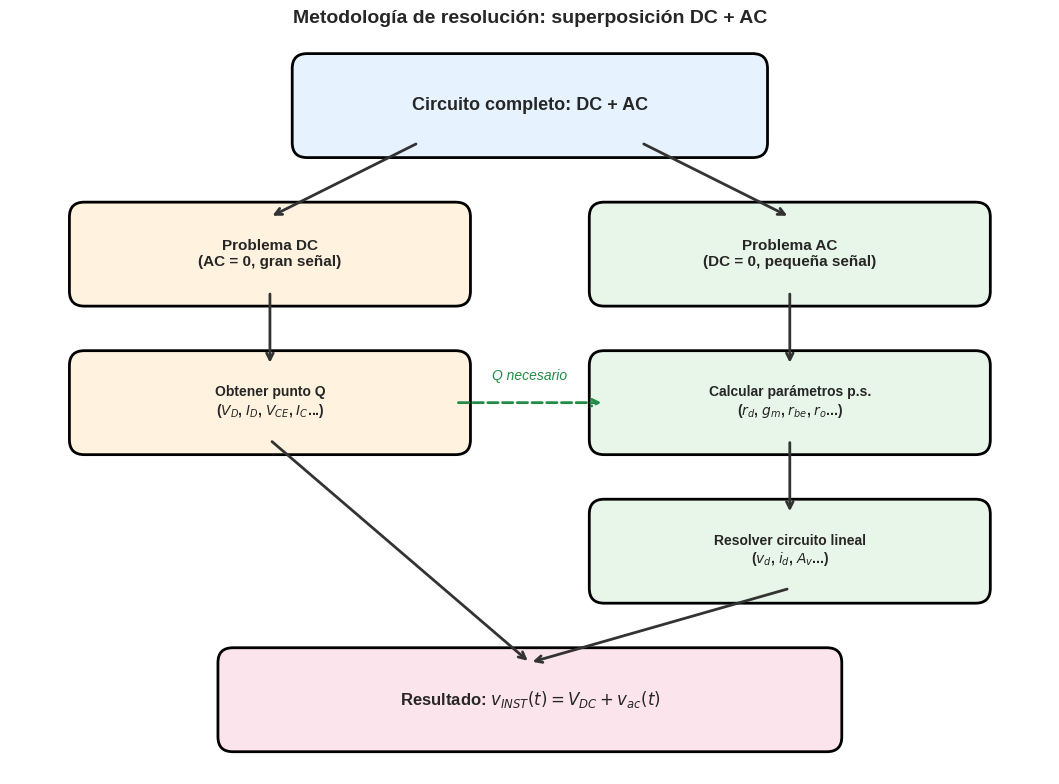

In [9]:
# Diagrama de flujo: metodología DC + AC
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.axis('off')

# Colores para las cajas
color_start = '#e6f3ff'
color_dc = '#fff3e0'
color_ac = '#e8f5e9'
color_end = '#fce4ec'

def draw_box(ax, x, y, w, h, text, color, fontsize=11):
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                          boxstyle='round,pad=0.2', facecolor=color,
                          edgecolor='black', lw=2)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center',
            fontsize=fontsize, fontweight='bold')

# Cajas
draw_box(ax, 7, 9, 6, 1, 'Circuito completo: DC + AC',
         color_start, 13)

draw_box(ax, 3.5, 7, 5, 1,
         'Problema DC\n(AC = 0, gran señal)', color_dc, 11)
draw_box(ax, 10.5, 7, 5, 1,
         'Problema AC\n(DC = 0, pequeña señal)', color_ac, 11)

draw_box(ax, 3.5, 5, 5, 1,
         r'Obtener punto Q' + '\n' +
         r'($V_D$, $I_D$, $V_{CE}$, $I_C$...)',
         color_dc, 10)
draw_box(ax, 10.5, 5, 5, 1,
         r'Calcular parámetros p.s.' + '\n' +
         r'($r_d$, $g_m$, $r_{be}$, $r_o$...)',
         color_ac, 10)

draw_box(ax, 10.5, 3, 5, 1,
         r'Resolver circuito lineal' + '\n' +
         r'($v_d$, $i_d$, $A_v$...)',
         color_ac, 10)

draw_box(ax, 7, 1, 8, 1,
         r'Resultado: $v_{INST}(t) = V_{DC} + v_{ac}(t)$',
         color_end, 12)

# Flechas
arrow_props = dict(arrowstyle='->', lw=2, color='#333333')
ax.annotate('', xy=(3.5, 7.5), xytext=(5.5, 8.5),
            arrowprops=arrow_props)
ax.annotate('', xy=(10.5, 7.5), xytext=(8.5, 8.5),
            arrowprops=arrow_props)
ax.annotate('', xy=(3.5, 5.5), xytext=(3.5, 6.5),
            arrowprops=arrow_props)
ax.annotate('', xy=(10.5, 5.5), xytext=(10.5, 6.5),
            arrowprops=arrow_props)

# Flecha de Q a parámetros AC
ax.annotate('', xy=(8, 5), xytext=(6, 5),
            arrowprops=dict(arrowstyle='->', lw=2,
                            color=COLOR_PUNTO, ls='--'))
ax.text(7, 5.3, 'Q necesario', fontsize=10, ha='center',
        color=COLOR_PUNTO, fontstyle='italic')

ax.annotate('', xy=(10.5, 3.5), xytext=(10.5, 4.5),
            arrowprops=arrow_props)
ax.annotate('', xy=(7, 1.5), xytext=(3.5, 4.5),
            arrowprops=arrow_props)
ax.annotate('', xy=(7, 1.5), xytext=(10.5, 2.5),
            arrowprops=arrow_props)

ax.set_title('Metodología de resolución: superposición DC + AC',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 9. Catálogo completo de ejercicios: todos los patrones

Esta sección clasifica todos los tipos de problemas que pueden aparecer en exámenes sobre modelos de pequeña señal.

| # | Tipo | Dispositivo | Ecuación clave | Dificultad |
|---|------|-------------|----------------|------------|
| 1 | Calcular $r_d$ del diodo | Diodo | $r_d = \phi_T / I_D$ | Baja |
| 2 | Calcular parámetros H del BJT | BJT | $h_{ie} = \beta \phi_T / I_C$ | Media |
| 3 | Calcular parámetros π del BJT | BJT | $g_m = I_C / \phi_T$ | Media |
| 4 | Convertir entre modelos H y π | BJT | $h_{fe} = g_m \cdot r_{be}$ | Media |
| 5 | Calcular $g_m$ y $r_o$ del MOSFET | MOSFET | $g_m = \sqrt{2 K_n I_D}$ | Media |
| 6 | Dibujar circuito equivalente AC | Cualquiera | Reglas de sustitución | Media-Alta |
| 7 | Análisis completo DC + AC | Cualquiera | Superposición | Alta |
| 8 | Comparar modelo simplificado vs completo | BJT | $h_{re}$, $h_{oe}$ | Media |

### 9.1 Tipo 1: Calcular $r_d$ del diodo desde el punto de operación

$$\boxed{r_d = \frac{\phi_T}{I_D}}$$

**Cuándo se usa:** siempre que se necesite el modelo de pequeña señal del diodo.

**Cómo afecta $I_D$:**
- Si **$I_D$ aumenta** $\to$ $r_d$ disminuye $\to$ el diodo se comporta como una resistencia más pequeña
- Si **$I_D$ disminuye** $\to$ $r_d$ aumenta $\to$ el diodo "opone más resistencia" a la señal AC

#### Ejercicio resuelto: Tipo 1

**Datos:** Diodo polarizado con $I_D = 0.5$ mA, $\phi_T = 26$ mV

**Paso 1:** Aplicar directamente la fórmula:

$$r_d = \frac{\phi_T}{I_D} = \frac{26\;\text{mV}}{0.5\;\text{mA}} = 52\;\Omega$$

**Resultado:** $\boxed{r_d = 52\;\Omega}$

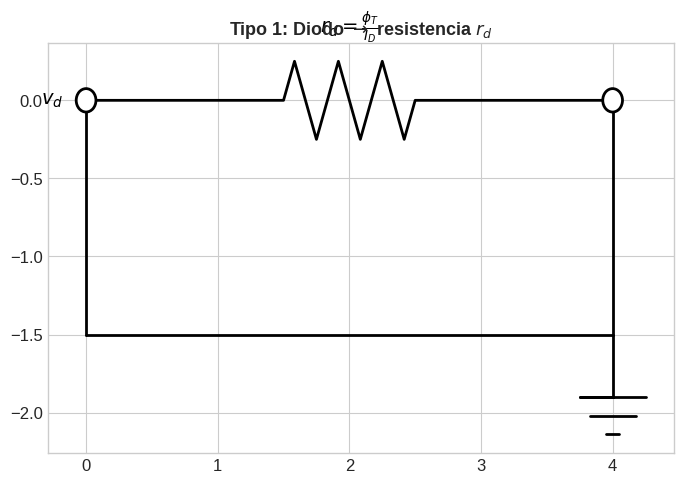

In [10]:
# Tipo 1: Modelo de pequeña señal del diodo
fig, ax = plt.subplots(figsize=(7, 5))
ax.set_title(r'Tipo 1: Diodo $\to$ resistencia $r_d$', fontsize=13, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.Dot(open=True).label(r'$v_d$', loc='left')
d += elm.Resistor().right().length(4).label(r'$r_d = \frac{\phi_T}{I_D}$', loc='top')
d += elm.Dot(open=True)
d += elm.Line().down().length(1.5)
d += elm.Ground()
d += elm.Line().left().length(4)
d += elm.Line().up().length(1.5)
d.draw()
plt.tight_layout(); plt.show()

### 9.2 Tipo 2: Calcular parámetros H del BJT desde el punto Q

$$\boxed{h_{ie} = \frac{\beta \cdot \phi_T}{I_C}} \qquad \boxed{h_{fe} = \beta} \qquad h_{re} = \frac{\phi_T}{V_A} \qquad h_{oe} = \frac{I_C}{V_A}$$

**Cuándo se usa:** cuando el enunciado pide explícitamente los parámetros H.

**Cómo afectan los parámetros:**
- Si **$I_C$ aumenta** $\to$ $h_{ie}$ disminuye (entrada de menor impedancia), $h_{oe}$ aumenta (salida menos ideal)
- Si **$\beta$ aumenta** $\to$ $h_{ie}$ aumenta, $h_{fe}$ aumenta
- Si **$V_A$ aumenta** $\to$ $h_{re} \to 0$, $h_{oe} \to 0$ (transistor más ideal)

#### Ejercicio resuelto: Tipo 2

**Datos:** $\beta = 200$, $I_C = 5$ mA, $V_A = 80$ V, $\phi_T = 26$ mV

**Paso 1:** Calcular $h_{ie}$:

$$h_{ie} = \frac{200 \times 26\;\text{mV}}{5\;\text{mA}} = \frac{5200\;\text{mV}}{5\;\text{mA}} = 1040\;\Omega \approx 1\;\text{k}\Omega$$

**Paso 2:** Los demás:

$$h_{fe} = \beta = 200$$

$$h_{re} = \frac{26 \times 10^{-3}}{80} = 3.25 \times 10^{-4} \approx 0$$

$$h_{oe} = \frac{5 \times 10^{-3}}{80} = 62.5\;\mu\text{S} \;\;(r_{ce} = 1/h_{oe} = 16\;\text{k}\Omega)$$

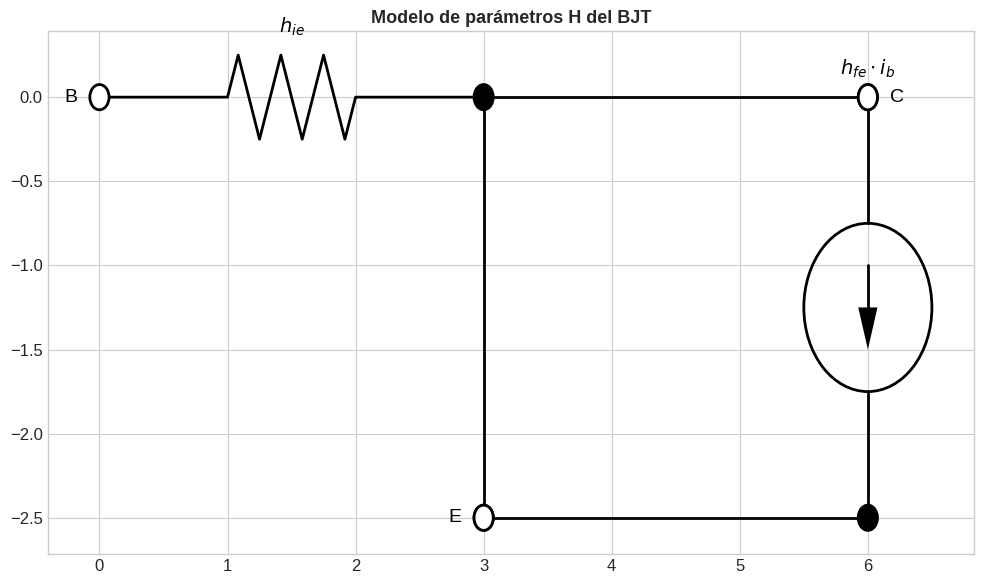

In [11]:
# Tipo 2: Modelo de parámetros H del BJT
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title(r'Modelo de parámetros H del BJT', fontsize=13, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
# Input side: B terminal
d += elm.Dot(open=True).label('B', loc='left')
d += elm.Resistor().right().length(3).label(r'$h_{ie}$', loc='top')
d += elm.Dot()
mid_in = d.here
d += elm.Line().down().length(2.5)
d += elm.Dot()
bot = d.here
d += elm.Dot(open=True).label('E', loc='left')
# Output side: current source
d += elm.Line().at(mid_in).right().length(3)
d += elm.Dot()
mid_out = d.here
d += elm.SourceI().down().length(2.5).label(r'$h_{fe} \cdot i_b$', loc='right')
d += elm.Dot()
d += elm.Line().left().tox(bot)
# Collector terminal
d += elm.Dot(open=True).at(mid_out).label('C', loc='right')
d.draw()
plt.tight_layout(); plt.show()

### 9.3 Tipo 3: Calcular parámetros π del BJT desde el punto Q

$$\boxed{g_m = \frac{I_C}{\phi_T}} \qquad \boxed{r_{be} = \frac{\beta}{g_m}} \qquad r_{ce} = \frac{V_A}{I_C}$$

**Cuándo se usa:** cuando el enunciado pide los parámetros π, o cuando se va a analizar el circuito AC.

**Cómo afectan:**
- Si **$I_C$ aumenta** $\to$ $g_m$ aumenta (más ganancia), $r_{be}$ disminuye, $r_{ce}$ disminuye
- $g_m$ es **independiente de $\beta$**

#### Ejercicio resuelto: Tipo 3

**Datos:** $\beta = 150$, $I_C = 1$ mA, $V_A = 120$ V, $\phi_T = 26$ mV

**Paso 1:** Transconductancia:

$$g_m = \frac{I_C}{\phi_T} = \frac{1\;\text{mA}}{26\;\text{mV}} = 38.46\;\text{mA/V}$$

**Paso 2:** Resistencia de entrada:

$$r_{be} = \frac{\beta}{g_m} = \frac{150}{38.46 \times 10^{-3}} = 3900\;\Omega = 3.9\;\text{k}\Omega$$

**Paso 3:** Resistencia de salida:

$$r_{ce} = \frac{V_A}{I_C} = \frac{120}{1 \times 10^{-3}} = 120\;\text{k}\Omega$$

### 9.4 Tipo 4: Convertir entre modelos H y π

Las relaciones de conversión son:

| De H a π | De π a H |
|----------|----------|
| $r_{be} = h_{ie}$ | $h_{ie} = r_{be}$ |
| $g_m = h_{fe} / h_{ie}$ | $h_{fe} = g_m \cdot r_{be}$ |
| $r_{ce} = 1 / h_{oe}$ | $h_{oe} = 1 / r_{ce}$ |

**Cuándo se usa:** cuando te dan un modelo y te piden trabajar con el otro.

#### Ejercicio resuelto: Tipo 4

**Datos:** $h_{ie} = 2.6$ k$\Omega$, $h_{fe} = 100$, $h_{oe} = 25\;\mu$S

**Paso 1:** Conversión directa:

$$r_{be} = h_{ie} = 2.6\;\text{k}\Omega$$

$$g_m = \frac{h_{fe}}{h_{ie}} = \frac{100}{2600} = 38.46\;\text{mA/V}$$

$$r_{ce} = \frac{1}{h_{oe}} = \frac{1}{25 \times 10^{-6}} = 40\;\text{k}\Omega$$

**Verificación:** $g_m \cdot r_{be} = 38.46 \times 10^{-3} \times 2600 = 100 = h_{fe}$ $\checkmark$

### 9.5 Tipo 5: Calcular parámetros de pequeña señal del MOSFET

$$\boxed{g_m = \sqrt{2 K_n I_D} = \frac{2 I_D}{V_{GS} - V_T}} \qquad \boxed{r_o = \frac{1}{\lambda \cdot I_D}}$$

**Cuándo se usa:** para cualquier circuito MOSFET en análisis AC.

**Cómo afectan:**
- Si **$I_D$ aumenta** $\to$ $g_m$ aumenta (pero con raíz cuadrada, menos que el BJT), $r_o$ disminuye
- Si **$K_n$ aumenta** $\to$ $g_m$ aumenta (transistor más ancho o con mejor tecnología)
- Si **$\lambda$ disminuye** $\to$ $r_o$ aumenta (canal más largo $\to$ salida más ideal)

#### Ejercicio resuelto: Tipo 5

**Datos:** $K_n = 2$ mA/V$^2$, $I_D = 0.5$ mA, $V_{GS} = 2$ V, $V_T = 0.8$ V, $\lambda = 0.05$ V$^{-1}$

**Paso 1:** Verificar coherencia. Si $I_D = (K_n/2)(V_{GS}-V_T)^2 = (2/2)(1.2)^2 = 1.44$ mA $\neq 0.5$ mA, entonces $I_D$ está fijado por el circuito.

**Paso 2:** Transconductancia usando $g_m = \sqrt{2 K_n I_D}$:

$$g_m = \sqrt{2 \times 2 \times 10^{-3} \times 0.5 \times 10^{-3}} = \sqrt{2 \times 10^{-6}} = 1.414\;\text{mA/V}$$

**Paso 3:** Resistencia de salida:

$$r_o = \frac{1}{\lambda \cdot I_D} = \frac{1}{0.05 \times 0.5 \times 10^{-3}} = 40\;\text{k}\Omega$$

**Resultado:** $g_m = 1.414$ mA/V, $r_o = 40$ k$\Omega$

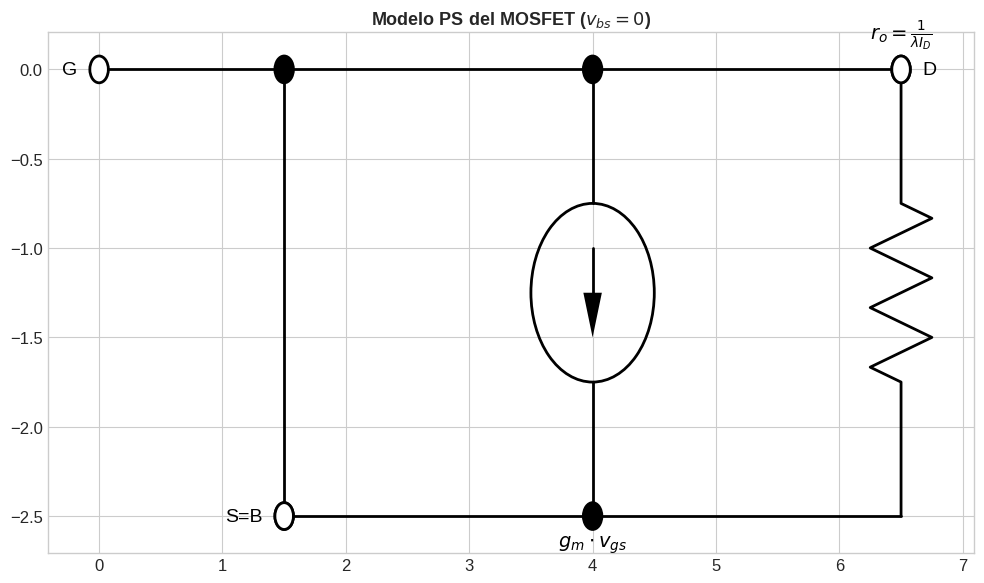

In [12]:
# Tipo 5: Modelo de pequeña señal del MOSFET (simplificado, vbs=0)
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title(r'Modelo PS del MOSFET ($v_{bs}=0$)', fontsize=13, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
# Gate - open (ig=0)
d += elm.Dot(open=True).label('G', loc='left')
d += elm.Line().right().length(1.5)
d += elm.Dot()
gate = d.here
d += elm.Line().down().length(2.5)
d += elm.Dot()
bot = d.here
d += elm.Dot(open=True).label('S=B', loc='left')
# gm source
d += elm.Line().at(gate).right().length(2.5)
d += elm.Dot()
top_mid = d.here
d += elm.SourceI().down().length(2.5).label(r'$g_m \cdot v_{gs}$', loc='left')
d += elm.Dot()
bot_mid = d.here
d += elm.Line().left().tox(bot)
# ro
d += elm.Line().at(top_mid).right().length(2.5)
d += elm.Dot()
top_r = d.here
d += elm.Resistor().down().length(2.5).label(r'$r_o = \frac{1}{\lambda I_D}$', loc='right')
d += elm.Line().left().tox(bot_mid)
# D terminal
d += elm.Dot(open=True).at(top_r).label('D', loc='right')
d.draw()
plt.tight_layout(); plt.show()

### 9.6 Tipo 6: Dibujar el circuito equivalente de pequeña señal

**Reglas de sustitución para pasar del circuito completo al circuito AC:**

1. **Fuentes DC de tensión** $\to$ cortocircuito (cable)
2. **Fuentes DC de corriente** $\to$ circuito abierto (eliminar)
3. **Condensadores de acoplo/desacoplo** $\to$ cortocircuito (a frecuencias de señal)
4. **Dispositivo no lineal** $\to$ su modelo de pequeña señal
5. **Resistencias** $\to$ se mantienen

#### Ejercicio resuelto: Tipo 6

**Enunciado:** Dado un circuito con un BJT en emisor común con $R_B$, $R_C$, $V_{CC}$ y un condensador de acoplo a la entrada, dibujar el circuito equivalente AC.

**Paso 1:** $V_{CC} \to$ cortocircuito a masa. Esto conecta un extremo de $R_C$ a masa.

**Paso 2:** Condensador de acoplo $\to$ cortocircuito. Conecta la fuente de señal directamente a la base.

**Paso 3:** BJT $\to$ modelo π simplificado ($r_{be}$ entre base-emisor, $g_m \cdot v_{be}$ de colector a emisor).

**Resultado:** La señal de entrada ve $R_B \| r_{be}$, y la salida es $-g_m \cdot v_{be} \cdot (R_C \| r_{ce})$.

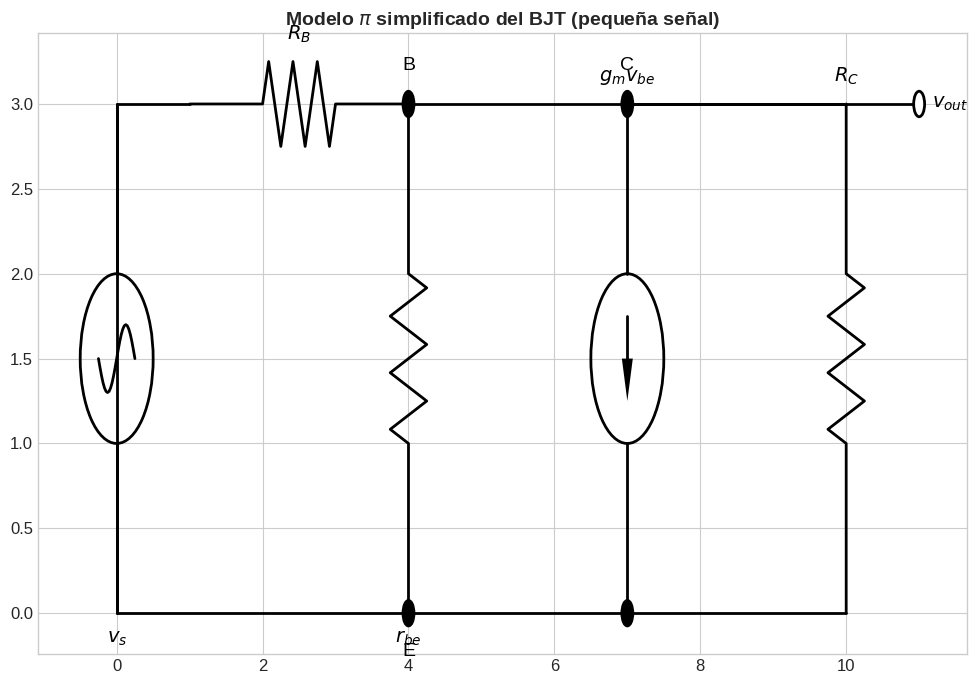

In [13]:
# Diagrama: circuito equivalente de pequeña señal del BJT
# (modelo pi simplificado en emisor común)
fig, ax = plt.subplots(figsize=(10, 7))
ax.set_title(r'Modelo $\pi$ simplificado del BJT (pequeña señal)',
             fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)

# Entrada: fuente de señal
d += elm.SourceSin().up().label(r'$v_s$', loc='left').length(3)
start = d.here

# Resistencia de base
d += elm.Line().right().length(1)
d += elm.Resistor().right().label(r'$R_B$', loc='top').length(3)

# Nodo base
d += elm.Dot().label('B', loc='top')
base_node = d.here

# r_be
d += elm.Resistor().down().label(r'$r_{be}$', loc='left').length(3)
d += elm.Dot().label('E', loc='bottom')
emitter_node = d.here

# Línea de masa inferior
d += elm.Line().left().tox(start)
d += elm.Line().up().toy(start)

# Fuente controlada (desde el nodo colector)
d += elm.Line().at(base_node).right().length(3)
d += elm.Dot().label('C', loc='top')
collector_node = d.here

d += elm.SourceI().down().label(r'$g_m v_{be}$', loc='right').length(3)
d += elm.Dot()
emitter_right = d.here

# R_C
d += elm.Line().at(collector_node).right().length(3)
d += elm.Resistor().down().label(r'$R_C$', loc='right').length(3)
d += elm.Line().left().tox(emitter_right)

# Línea de masa
d += elm.Line().at(emitter_right).left().tox(emitter_node)

# Salida
d += elm.Line().at(collector_node).right().length(3)
d += elm.Line().right().length(1)
d += elm.Dot(open=True).label(r'$v_{out}$', loc='right')

d.draw()
plt.tight_layout()
plt.show()

### 9.7 Tipo 7: Análisis completo DC + AC (el más importante)

Este es el tipo de ejercicio más completo y frecuente en exámenes. Sigue los tres pasos de la superposición:

**Paso 1 - DC:** Apagar fuentes AC, usar modelo de gran señal, obtener punto Q.

**Paso 2 - Parámetros:** Con el punto Q, calcular $g_m$, $r_{be}$, $r_{ce}$, etc.

**Paso 3 - AC:** Apagar fuentes DC, sustituir dispositivo por modelo de pequeña señal, resolver.

#### Ejercicio resuelto: Tipo 7

**Enunciado:** Circuito emisor común con $V_{CC} = 12$ V, $R_B = 470$ k$\Omega$, $R_C = 4.7$ k$\Omega$, $\beta = 100$, $V_A = 100$ V. Encontrar la ganancia de tensión $A_v = v_{out}/v_{in}$.

**Paso 1 - Análisis DC:**

$$I_B = \frac{V_{CC} - V_{BE}}{R_B} = \frac{12 - 0.7}{470\;\text{k}\Omega} = 24.04\;\mu\text{A}$$

$$I_C = \beta \cdot I_B = 100 \times 24.04\;\mu\text{A} = 2.404\;\text{mA}$$

$$V_{CE} = V_{CC} - R_C \cdot I_C = 12 - 4.7 \times 2.404 = 0.70\;\text{V}$$

$V_{CE} = 0.70$ V $> 0.2$ V $\to$ **Activa confirmada** (apenas).

**Paso 2 - Parámetros de pequeña señal:**

$$g_m = \frac{I_C}{\phi_T} = \frac{2.404\;\text{mA}}{26\;\text{mV}} = 92.46\;\text{mA/V}$$

$$r_{be} = \frac{\beta}{g_m} = \frac{100}{92.46 \times 10^{-3}} = 1081.6\;\Omega \approx 1.08\;\text{k}\Omega$$

$$r_{ce} = \frac{V_A}{I_C} = \frac{100}{2.404 \times 10^{-3}} = 41.6\;\text{k}\Omega$$

**Paso 3 - Análisis AC (modelo π simplificado):**

La ganancia de tensión del emisor común (despreciando $r_{ce}$):

$$\boxed{A_v = -g_m \cdot R_C = -92.46 \times 10^{-3} \times 4700 = -434.6}$$

> **Con modelo completo** ($r_{ce}$ en paralelo con $R_C$): $R_C \| r_{ce} = \frac{4700 \times 41600}{4700 + 41600} = 4222\;\Omega$

$$A_v = -g_m \cdot (R_C \| r_{ce}) = -92.46 \times 10^{-3} \times 4222 = -390.3$$

La diferencia es del 10%, lo que justifica usar el modelo simplificado en muchos casos.

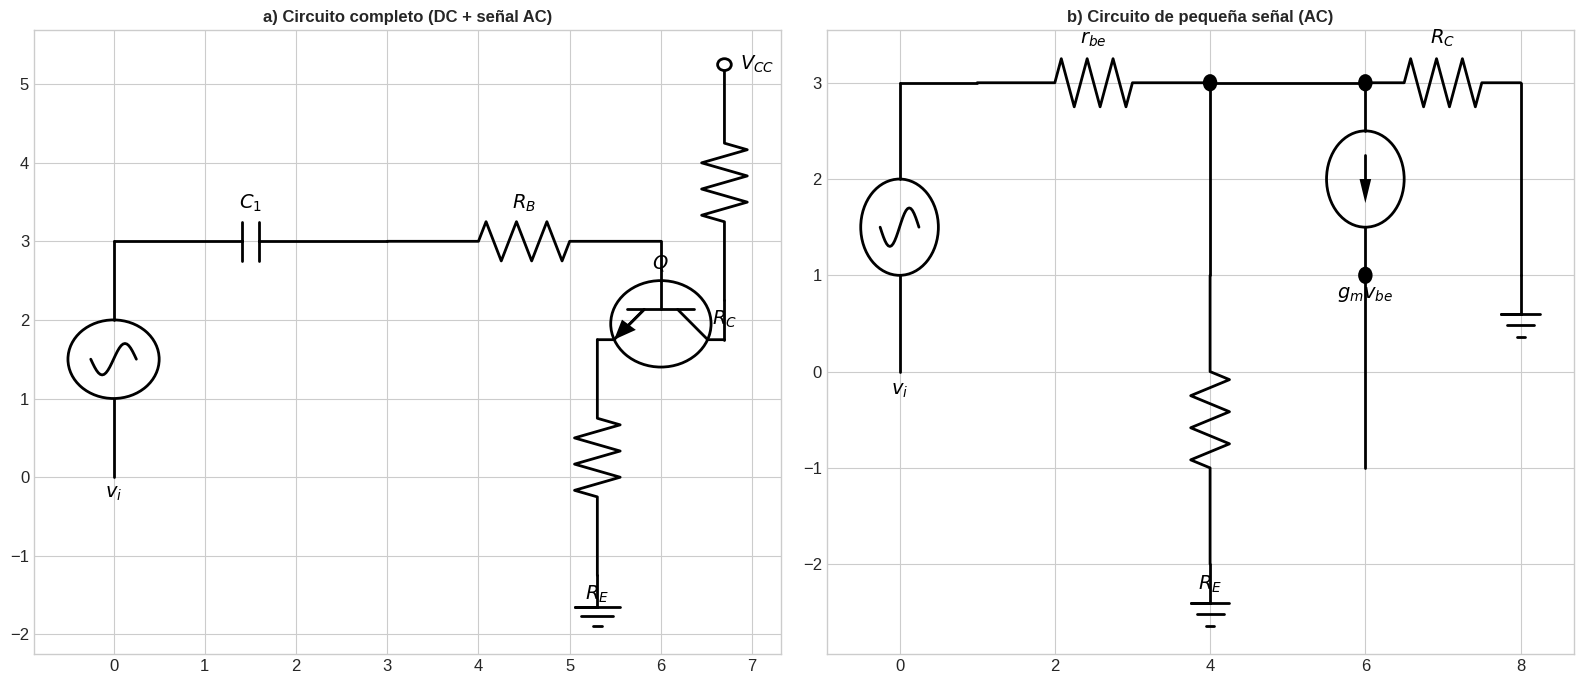

In [14]:
# Tipo 7: Ejemplo completo DC+AC - circuito original y equivalente PS
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# a) Circuito original (DC + AC)
ax = axes[0]
ax.set_title(r'a) Circuito completo (DC + señal AC)', fontsize=12, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
# Signal source
d += elm.SourceSin().up().label(r'$v_i$', loc='left')
d += elm.Capacitor().right().label(r'$C_1$', loc='top')
d += elm.Resistor().right().label(r'$R_B$', loc='top')
d += elm.Line().down().length(0.5)
d += elm.BjtNpn(circle=True).anchor('base').label(r'$Q$', loc='right')
bjt = d.elements[-1]
d += elm.Resistor().at(bjt.emitter).down().label(r'$R_E$', loc='left')
d += elm.Ground()
d += elm.Line().at(bjt.collector).up().length(0.5)
d += elm.Resistor().up().label(r'$R_C$', loc='left')
d += elm.Dot(open=True).label(r'$V_{CC}$', loc='right')
d.draw()

# b) Equivalente de pequeña señal
ax = axes[1]
ax.set_title(r'b) Circuito de pequeña señal (AC)', fontsize=12, fontweight='bold')
d2 = schemdraw.Drawing(canvas=ax)
d2 += elm.SourceSin().up().label(r'$v_i$', loc='left')
d2 += elm.Line().right().length(1)
# rbe
d2 += elm.Resistor().right().label(r'$r_{be}$', loc='top')
d2 += elm.Dot()
mid = d2.here
d2 += elm.Line().down().length(2)
d2 += elm.Resistor().down().label(r'$R_E$', loc='left')
d2 += elm.Ground()
# gm source
d2 += elm.Line().at(mid).right().length(2)
d2 += elm.Dot()
col = d2.here
d2 += elm.SourceI().down().length(2).label(r'$g_m v_{be}$', loc='left')
d2 += elm.Dot()
d2 += elm.Line().down().toy(d2.elements[-3].end)
# RC
d2 += elm.Resistor().at(col).right().length(2).label(r'$R_C$', loc='top')
d2 += elm.Line().down().length(2)
d2 += elm.Ground()
d2.draw()

plt.tight_layout(); plt.show()

### 9.8 Tipo 8: Comparar modelo simplificado vs completo

**Modelo H simplificado** (despreciando $h_{re}$ y $h_{oe}$):

| Parámetro despreciado | Condición para despreciar | Error típico |
|-----------------------|--------------------------|-------------|
| $h_{re} \approx 0$ | $h_{re} \ll 1$ | Siempre válido ($\sim 10^{-4}$) |
| $h_{oe} \approx 0$ | $R_C \ll r_{ce}$ | Válido si $R_C < 0.1 \cdot r_{ce}$ |

**Cuándo NO se puede simplificar:**
- Si $R_C$ es comparable a $r_{ce}$ (por ejemplo, $R_C = 20$ k$\Omega$ y $r_{ce} = 50$ k$\Omega$)
- Si el enunciado pide explícitamente la resistencia de salida del amplificador
- Si se pide calcular el error de la simplificación

#### Ejercicio resuelto: Tipo 8

**Datos:** $\beta = 100$, $I_C = 0.5$ mA, $V_A = 50$ V, $R_C = 10$ k$\Omega$

**Paso 1:** Calcular parámetros:

$$g_m = \frac{0.5}{26} = 19.23\;\text{mA/V} \qquad r_{ce} = \frac{50}{0.5 \times 10^{-3}} = 100\;\text{k}\Omega$$

**Paso 2:** Ganancia simplificada:

$$A_{v,simp} = -g_m \cdot R_C = -19.23 \times 10^{-3} \times 10000 = -192.3$$

**Paso 3:** Ganancia completa:

$$R_C \| r_{ce} = \frac{10000 \times 100000}{10000 + 100000} = 9091\;\Omega$$

$$A_{v,comp} = -g_m \cdot (R_C \| r_{ce}) = -19.23 \times 10^{-3} \times 9091 = -174.8$$

**Error relativo:**

$$\text{Error} = \frac{|-192.3 - (-174.8)|}{|-174.8|} \times 100 = 10.0\%$$

> **Conclusión:** Con $R_C / r_{ce} = 0.1$, el error es del 10%. Regla práctica: si $R_C < 0.1 \cdot r_{ce}$, la simplificación introduce menos del 10% de error.

### Tabla resumen de fórmulas por tipo

| # | Tipo | Fórmula clave | Dato necesario |
|---|------|---------------|----------------|
| 1 | $r_d$ del diodo | $r_d = \phi_T / I_D$ | $I_D$ |
| 2 | Parámetros H | $h_{ie} = \beta \phi_T / I_C$ | $\beta$, $I_C$, $V_A$ |
| 3 | Parámetros π | $g_m = I_C / \phi_T$ | $I_C$, $\beta$, $V_A$ |
| 4 | Conversión H $\leftrightarrow$ π | $h_{fe} = g_m \cdot r_{be}$ | Parámetros de un modelo |
| 5 | MOSFET $g_m$, $r_o$ | $g_m = \sqrt{2 K_n I_D}$ | $K_n$, $I_D$, $\lambda$ |
| 6 | Circuito equiv. AC | Reglas de sustitución | Circuito completo |
| 7 | DC + AC completo | Superposición | Todo el circuito |
| 8 | Simpl. vs completo | $R_C \| r_{ce}$ | $R_C$, $r_{ce}$ |

---

## 10. Resumen y tabla comparativa

### Tabla de fórmulas clave

| Parámetro | Diodo | BJT | MOSFET |
|-----------|-------|-----|--------|
| **Modelo clave** | $r_d = \phi_T / I_D$ | $h_{ie}$, $h_{fe}$ (ó $r_{be}$, $g_m$) | $g_m$, $r_o$ |
| **Impedancia de entrada** | $r_d$ | $r_{be} = \beta \cdot \phi_T / I_C$ | $\infty$ ($i_g = 0$) |
| **Elemento de ganancia** | — | $g_m \cdot v_{be}$ ó $\beta \cdot i_b$ | $g_m \cdot v_{gs}$ |
| **Impedancia de salida** | — | $r_{ce} = V_A / I_C$ | $r_o = 1 / (\lambda \cdot I_D)$ |
| **Transconductancia** | $g_d = I_D / \phi_T$ | $g_m = I_C / \phi_T$ | $g_m = \sqrt{2 K_n I_D}$ |

### Ideas clave para recordar

1. **Pequeña señal = linealización** alrededor del punto de operación Q
2. Los parámetros de pequeña señal **dependen del punto Q** (hay que calcularlo primero)
3. El **diodo** se reduce a una resistencia $r_d$
4. El **BJT** tiene dos modelos equivalentes: H (con $i_b$ como variable) y π (con $v_{be}$ como variable)
5. El **MOSFET** tiene entrada de impedancia infinita ($i_g = 0$) y requiere tres parámetros: $g_m$, $g_{mb}$, $g_o$
6. Para resolver circuitos mixtos: **separar DC y AC** mediante superposición
7. En el circuito AC: fuentes DC $\to$ cortocircuito/abierto, condensadores $\to$ cortocircuito